In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import sys
sys.path.append("/content/drive/MyDrive/stocks/duet_class")

from pipeline.config import DUETConfig
from pipeline import preprocess, train, evaluate, predict
from duet.model import DUETModel
from torch.utils.data import DataLoader, TensorDataset
import torch
import joblib
import random

import numpy as np
from sklearn.utils.class_weight import compute_class_weight

In [ ]:
# Настройки
joblib_path = "/content/drive/MyDrive/stocks/Data/NEARUSDT/nearusdt_ob_indicators_TF_5_metric_v2-long_rsi_labels-1.joblib"
device = "cuda" if torch.cuda.is_available() else "cpu"

config = DUETConfig(
    # =========================
    # Общие параметры
    # =========================
    timestamp_col = "Time_close",
    features = [
       'Open', 'High', 'Low', 'Close',
       'Volume',
      #  'sigma_bollinger_7','sigma_bollinger_14',
      #  'sigma_log_return_7',  'sigma_true_range_7', 'min_extr_distance_7',
      #  'max_extr_distance_7', 'efficiency_ratio_7',
      #  'sigma_log_return_14',  'sigma_true_range_14', 'min_extr_distance_14',
      #  'max_extr_distance_14', 'efficiency_ratio_14'
       'up_bb','low_bb','RSI_Close',
      #  'Depth_ratio_1','Depth_ratio_3','Depth_ratio_5','Depth_ratio_5','Depth_ratio_15',
        # 'Depth_ask_1','Depth_bid_1','Depth_ask_3','Depth_bid_3','Depth_ask_5','Depth_bid_5','Depth_ask_8','Depth_bid_8','Depth_ask_15','Depth_bid_15',
      #  'RSI_Depth_ask_1','RSI_Depth_ask_3','RSI_Depth_ask_5','RSI_Depth_ask_8','RSI_Depth_bid_1','RSI_Depth_bid_3','RSI_Depth_bid_5','RSI_Depth_bid_8',
      #  'Depth_ratio_30_k','Depth_ratio_15_k',
       'Depth_ratio_8_k','Depth_ratio_5_k','Depth_ratio_3_k',
       'Total_depth_1','Total_depth_3','Total_depth_5','Total_depth_8','Total_depth_15',
       'Impulse_1','Impulse_3','Impulse_5','Impulse_8','Impulse_15',
      #  'Velocity_1','Velocity_3','Velocity_5','Velocity_8','Velocity_15',
      #  'count_long_short_ratio', 'sum_taker_long_short_vol_ratio',
      #  'Depth_imbalance_1','Depth_imbalance_3','Depth_imbalance_5','Depth_imbalance_8','Depth_imbalance_15',
    ],                           # Название колонок для обучения
    forecast = 'Labels2:',          # Название колонки с таргетом
    not_to_normalise = [],       # Название колонок, которые НЕ НАДО нормализовать
    scaler = 'MINMAX',         # Тип нормализации (STD, MINMAX, QUANT)
    predict_type = 'detect',     # Детекция "detect" или предикт "next" следующей свечи
    seq_len = 48,                # Длина входной последовательности
    num_classes = 3,             # кол-во классов
    patch_len = 24,               # Длина патча (TCM)
    stride = 12,                  # Шаг между патчами (TCM)
    moving_avg = 25,              # Размер окна скользящего сглаживания

    # =========================
    # Параметры модели
    # =========================
    d_model = 64,               # Размерность скрытого пространства в attention
    d_ff = 256,                 # Размерность feedforward слоя
    n_heads = 4,                # Количество голов в multi-head attention
    e_layers = 2,               # Количество слоев в encoder (CCM)
    dropout = 0.2,            # Dropout во всех слоях attention
    fc_dropout = 0.2,         # Dropout в выходном head слое
    activation = "relu",        # Активационная функция (relu, gelu, elu)
    num_experts = 4,            # Число экспертов (в Router, если используется)
    report_freq = 10,            # Частота появления confusion matrix

    # =========================
    # Режимы обработки
    # =========================
    CI = True,                 # Channel-Independent режим (если False — shared weights)
    use_router = True,          # Включить распределительный роутер
    timeenc = 1,                # Использовать time encoding (0 = без, 1 = sin/cos и т.п.)

    # =========================
    # Настройки обучения
    # =========================
    batch_size=32,          # можно немного увеличить при хорошем GPU
    epochs=300,             # больше эпох для более тонкой настройки
    learning_rate=5e-4,     # стандартный LR для Adam
    weight_decay=1e-5,
    patience=300,            # early stopping не слишком строгий

    # =========================
    # Прочее
    # =========================
    checkpoint_best = '/content/drive/MyDrive/stocks/duet_class/weights/best_val_acc_weights_001.pt',       # Путь для сохранения лучших по val_accuracy весов
    checkpoint_final = '/content/drive/MyDrive/stocks/duet_class/weights/final_weights_001.pt',      # Путь для сохранения финальных весов
    seed = 11,                  # Фиксированное зерно генератора случайных чисел
    verbose = True,            # Печать хода обучения
)

"""
Устанавливает seed для numpy, random, torch (вкл. CUDA).
Гарантирует воспроизводимость.
"""

random.seed(config.seed)
np.random.seed(config.seed)
torch.manual_seed(config.seed)
torch.cuda.manual_seed_all(config.seed)

In [ ]:
df = joblib.load(joblib_path)
df['Time_close'] = df['Time_close'] / 1000
df.columns

Index(['Time_close', 'Best_bid', 'Best_ask', 'Current_price', 'Depth_bid_90',
       'Depth_ask_90', 'Slope_bid_90', 'Slope_ask_90', 'Total_depth_90',
       'Depth_imbalance_90',
       ...
       'Depth_ratio_15_k', 'Depth_ratio_30_k', 'middle_bb', '20dSTD', 'up_bb',
       'low_bb', 'RSI_Close_30', 'Labels:', 'Labels2:', 'ratio_bb'],
      dtype='object', length=144)

In [ ]:
import pandas as pd

def efficiency_ratio(series: pd.Series, window: int) -> pd.Series:
    # Направленное изменение
    direction = series.diff(window).abs()

    # Шум: сумма абсолютных изменений внутри окна
    volatility = series.diff().abs().rolling(window=window).sum()

    # ER = направленное / суммарное
    er = direction / volatility

    return er

df['er_15'] = efficiency_ratio(df['Close'], window=15)
df['er_30'] = efficiency_ratio(df['Close'], window=30)
# df['er_60'] = efficiency_ratio(df['Close'], window=60)
# df['er_90'] = efficiency_ratio(df['Close'], window=90)

Индекс уже в формате datetime
Инферированная частота: 5min
Пропусков в индексе не обнаружено
Окончательно удалено 0 строк содеражащих NaN
Балансируем до 1079 примеров на класс
Балансируем до 310 примеров на класс
Классы после балансировки: {np.float64(0.0): np.int64(1079), np.float64(1.0): np.int64(1079), np.float64(2.0): np.int64(1079)}
Распределение весов между класcами tensor([1., 1., 1.], device='cuda:0')


[1/300] Train Loss: 1.0981 | Train Acc: 0.3490 | Val Loss: 1.0843 | Val Acc: 0.4094
Saving best val_acc model weights to /content/drive/MyDrive/stocks/duet_class/weights/best_val_acc_weights_001.pt


[2/300] Train Loss: 1.0562 | Train Acc: 0.4317 | Val Loss: 1.0245 | Val Acc: 0.4729
Saving best val_acc model weights to /content/drive/MyDrive/stocks/duet_class/weights/best_val_acc_weights_001.pt


[3/300] Train Loss: 1.0139 | Train Acc: 0.4681 | Val Loss: 0.9865 | Val Acc: 0.5167
Saving best val_acc model weights to /content/drive/MyDrive/stocks/duet_class/weights/best_val_acc_weights_001.pt


[4/300] Train Loss: 1.0101 | Train Acc: 0.4788 | Val Loss: 0.9797 | Val Acc: 0.5104
Saving best val_acc model weights to /content/drive/MyDrive/stocks/duet_class/weights/best_val_acc_weights_001.pt


...

[6/300] Train Loss: 0.9697 | Train Acc: 0.5156 | Val Loss: 0.9641 | Val Acc: 0.5333
Saving best val_acc model weights to /content/drive/MyDrive/stocks/duet_class/weights/best_val_acc_weights_001.pt


[7/300] Train Loss: 0.9599 | Train Acc: 0.5183 | Val Loss: 0.9717 | Val Acc: 0.5177


[8/300] Train Loss: 0.9400 | Train Acc: 0.5520 | Val Loss: 0.9637 | Val Acc: 0.5177
Saving best val_acc model weights to /content/drive/MyDrive/stocks/duet_class/weights/best_val_acc_weights_001.pt


[9/300] Train Loss: 0.9380 | Train Acc: 0.5468 | Val Loss: 0.9387 | Val Acc: 0.5531
Saving best val_acc model weights to /content/drive/MyDrive/stocks/duet_class/weights/best_val_acc_weights_001.pt


[10/300] Train Loss: 0.9310 | Train Acc: 0.5656 | Val Loss: 0.9568 | Val Acc: 0.5354


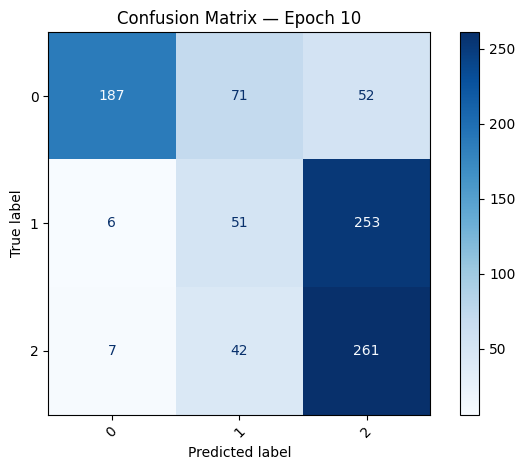

[11/300] Train Loss: 0.9283 | Train Acc: 0.5623 | Val Loss: 0.9275 | Val Acc: 0.5885
Saving best val_acc model weights to /content/drive/MyDrive/stocks/duet_class/weights/best_val_acc_weights_001.pt


[12/300] Train Loss: 0.9199 | Train Acc: 0.5737 | Val Loss: 0.9372 | Val Acc: 0.5635


[13/300] Train Loss: 0.9164 | Train Acc: 0.5806 | Val Loss: 0.9372 | Val Acc: 0.5385


[14/300] Train Loss: 0.9157 | Train Acc: 0.5736 | Val Loss: 0.9178 | Val Acc: 0.5865
Saving best val_acc model weights to /content/drive/MyDrive/stocks/duet_class/weights/best_val_acc_weights_001.pt


[15/300] Train Loss: 0.9197 | Train Acc: 0.5764 | Val Loss: 0.9223 | Val Acc: 0.5719


[16/300] Train Loss: 0.9103 | Train Acc: 0.5831 | Val Loss: 0.9124 | Val Acc: 0.5792
Saving best val_acc model weights to /content/drive/MyDrive/stocks/duet_class/weights/best_val_acc_weights_001.pt


[17/300] Train Loss: 0.9042 | Train Acc: 0.5972 | Val Loss: 0.9082 | Val Acc: 0.6083
Saving best val_acc model weights to /content/drive/MyDrive/stocks/duet_class/weights/best_val_acc_weights_001.pt


[18/300] Train Loss: 0.8999 | Train Acc: 0.5932 | Val Loss: 0.9106 | Val Acc: 0.5969


[19/300] Train Loss: 0.8975 | Train Acc: 0.6128 | Val Loss: 0.9237 | Val Acc: 0.5708


[20/300] Train Loss: 0.8913 | Train Acc: 0.6086 | Val Loss: 0.9205 | Val Acc: 0.5687


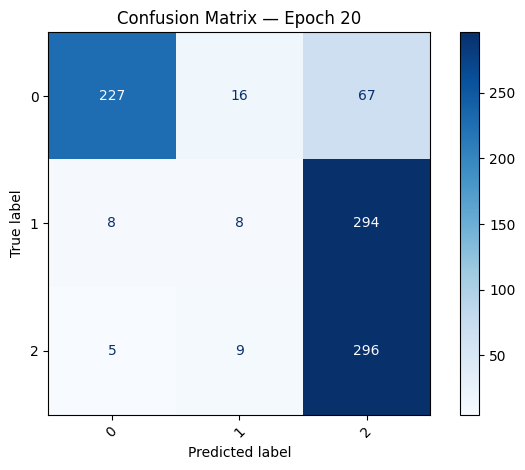

[21/300] Train Loss: 0.9037 | Train Acc: 0.5990 | Val Loss: 0.9252 | Val Acc: 0.5687


[22/300] Train Loss: 0.8995 | Train Acc: 0.6116 | Val Loss: 0.9082 | Val Acc: 0.6010


[23/300] Train Loss: 0.8950 | Train Acc: 0.6232 | Val Loss: 0.9121 | Val Acc: 0.6052


[24/300] Train Loss: 0.8902 | Train Acc: 0.6137 | Val Loss: 0.9057 | Val Acc: 0.5687
Saving best val_acc model weights to /content/drive/MyDrive/stocks/duet_class/weights/best_val_acc_weights_001.pt


[25/300] Train Loss: 0.8892 | Train Acc: 0.6244 | Val Loss: 0.9135 | Val Acc: 0.6042


[26/300] Train Loss: 0.8941 | Train Acc: 0.6097 | Val Loss: 0.9107 | Val Acc: 0.6062


[27/300] Train Loss: 0.8937 | Train Acc: 0.6119 | Val Loss: 0.9056 | Val Acc: 0.6000
Saving best val_acc model weights to /content/drive/MyDrive/stocks/duet_class/weights/best_val_acc_weights_001.pt


[28/300] Train Loss: 0.8790 | Train Acc: 0.6257 | Val Loss: 0.9104 | Val Acc: 0.6094


[29/300] Train Loss: 0.8821 | Train Acc: 0.6238 | Val Loss: 0.8983 | Val Acc: 0.6083
Saving best val_acc model weights to /content/drive/MyDrive/stocks/duet_class/weights/best_val_acc_weights_001.pt


[30/300] Train Loss: 0.8852 | Train Acc: 0.6295 | Val Loss: 0.8949 | Val Acc: 0.6083


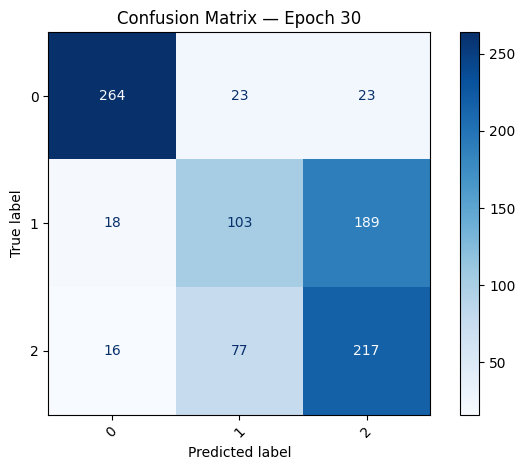

Saving best val_acc model weights to /content/drive/MyDrive/stocks/duet_class/weights/best_val_acc_weights_001.pt


[31/300] Train Loss: 0.8783 | Train Acc: 0.6308 | Val Loss: 0.8985 | Val Acc: 0.6125


[32/300] Train Loss: 0.8777 | Train Acc: 0.6332 | Val Loss: 0.8950 | Val Acc: 0.6115


[33/300] Train Loss: 0.8828 | Train Acc: 0.6403 | Val Loss: 0.9173 | Val Acc: 0.5719


[34/300] Train Loss: 0.8777 | Train Acc: 0.6335 | Val Loss: 0.8978 | Val Acc: 0.6094


...

[36/300] Train Loss: 0.8809 | Train Acc: 0.6354 | Val Loss: 0.8989 | Val Acc: 0.5917


[37/300] Train Loss: 0.8730 | Train Acc: 0.6388 | Val Loss: 0.8995 | Val Acc: 0.5958


[38/300] Train Loss: 0.8668 | Train Acc: 0.6591 | Val Loss: 0.8938 | Val Acc: 0.6000
Saving best val_acc model weights to /content/drive/MyDrive/stocks/duet_class/weights/best_val_acc_weights_001.pt


[39/300] Train Loss: 0.8679 | Train Acc: 0.6552 | Val Loss: 0.8853 | Val Acc: 0.6208
Saving best val_acc model weights to /content/drive/MyDrive/stocks/duet_class/weights/best_val_acc_weights_001.pt


[40/300] Train Loss: 0.8724 | Train Acc: 0.6523 | Val Loss: 0.9004 | Val Acc: 0.6188


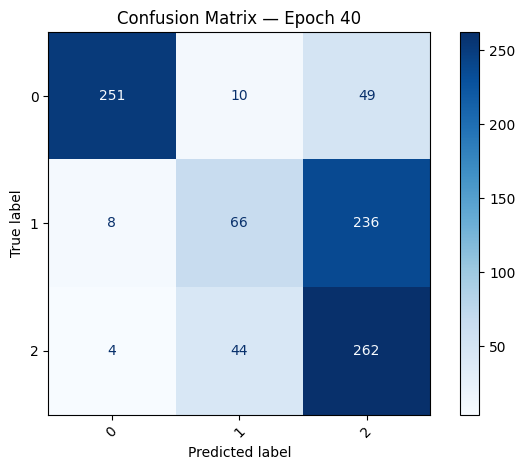

[41/300] Train Loss: 0.8668 | Train Acc: 0.6551 | Val Loss: 0.9064 | Val Acc: 0.6021


[42/300] Train Loss: 0.8613 | Train Acc: 0.6640 | Val Loss: 0.9010 | Val Acc: 0.6125


[43/300] Train Loss: 0.8597 | Train Acc: 0.6650 | Val Loss: 0.8980 | Val Acc: 0.5948


In [ ]:
# --- 1. Предобработка данных ---
# Загрузка данных
# df = joblib.load(joblib_path)
df = preprocess.prepare_time_series(df, config) # проверка пропусков, установка datetime индекса
preprocess.check_data(df, config) # проверка на nan & inf
df_train, df_val = preprocess.split_dataframe(df, train_ratio=0.75)

# --- 2. Создание окон и меток ---
# Предположим, что у вас есть отдельная колонка с метками классов: например, 'target'
# Если нет, то вам нужно определить логику создания меток из временных окон

# Создаем окна и метки классов
x_train, y_train = preprocess.prepare_windows(df_train, config)
x_val, y_val = preprocess.prepare_windows(df_val, config)


# Балансируем (если не нужно, то закомментировать)
x_train, y_train = preprocess.balance_windows(x_train, y_train)
x_val, y_val = preprocess.balance_windows(x_val, y_val)

# Проверяем балансировку
unique, counts = np.unique(y_train, return_counts=True)
print("Классы после балансировки:", dict(zip(unique, counts)))

# --- 3. Подсчет весов классов ---
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)
print(f"Распределение весов между класcами {class_weights}")

# --- 4. Создание DataLoader'ов ---
train_dataset = TensorDataset(
    torch.tensor(x_train, dtype=torch.float32),
    torch.tensor(y_train, dtype=torch.long)
)
val_dataset = TensorDataset(
    torch.tensor(x_val, dtype=torch.float32),
    torch.tensor(y_val, dtype=torch.long)
)

train_loader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=config.batch_size)

# --- 6. Инициализация модели ---
model = DUETModel(config).to(device)

# --- 7. Обучение модели ---
trained_model = train.train_model(
    model,
    config,
    train_loader,
    val_loader,
    device=device,
    class_weights = class_weights
)


              precision    recall  f1-score   support

           0       0.99      1.00      1.00    116011
           1       0.00      0.00      0.00       388
           2       0.00      0.00      0.00       310

    accuracy                           0.99    116709
   macro avg       0.33      0.33      0.33    116709
weighted avg       0.99      0.99      0.99    116709


Metrics:
ACCURACY: 0.99
MACRO_PRECISION: 0.33
MACRO_RECALL: 0.33
MACRO_F1: 0.33


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/m

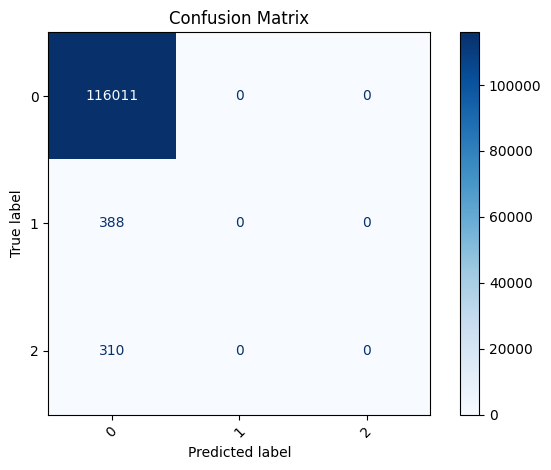


Examples of predictions:
Sample 41956: True=0, Pred=0 ✅
Sample 78116: True=0, Pred=0 ✅
Sample 98173: True=0, Pred=0 ✅
Sample 38819: True=0, Pred=0 ✅
Sample 21016: True=0, Pred=0 ✅
Sample 10679: True=0, Pred=0 ✅
Sample 6428: True=0, Pred=0 ✅
Sample 42945: True=0, Pred=0 ✅
Sample 43724: True=0, Pred=0 ✅
Sample 100473: True=0, Pred=0 ✅


In [ ]:
# Оценка модели
y_true, y_pred = evaluate.evaluate_model(model, val_loader, device="cuda")

# Подсчёт метрик
metrics = evaluate.compute_metrics(y_true, y_pred)
print("\nMetrics:")
for metric, value in metrics.items():
    print(f"{metric.upper()}: {value:.2f}")


# Матрица ошибок
evaluate.plot_confusion_matrix(y_true, y_pred)

# Примеры предсказаний
evaluate.plot_classification_examples(y_true, y_pred, n=10)

In [ ]:
# Загрузка весов

model.load_state_dict(torch.load(config.checkpoint_best)) # загрузка лучших весов
# model.load_state_dict(torch.load(config.checkpoint_final)) # загрузка финальных весов
model.eval()

DUETModel(
  (tcm): TCM(
    (decomp): SeriesDecomposition(
      (avg_pool): AvgPool1d(kernel_size=(25,), stride=(1,), padding=(12,))
    )
    (extractor): LinearPatternExtractor(
      (projection): ModuleList(
        (0): Linear(in_features=48, out_features=64, bias=True)
      )
      (dropout): Dropout(p=0.2, inplace=False)
    )
  )
  (ccm): CCM(
    (enc_layers): ModuleList(
      (0-1): 2 x EncoderLayer(
        (attn): MultiHeadSelfAttention(
          (qkv_proj): Linear(in_features=64, out_features=192, bias=True)
          (out_proj): Linear(in_features=64, out_features=64, bias=True)
          (dropout): Dropout(p=0.2, inplace=False)
        )
        (dropout1): Dropout(p=0.2, inplace=False)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (activation): ReLU()
        (ffn): Sequential(
          (0): Linear(in_features=64, out_features=256, bias=True)
          (1): ReLU()
          (2): Dropout(p=0.2, inplace=False)
          (3): Linear(in

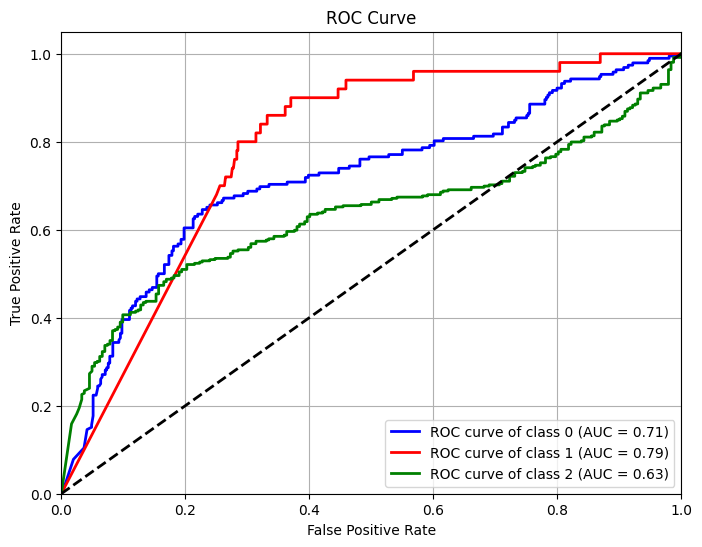

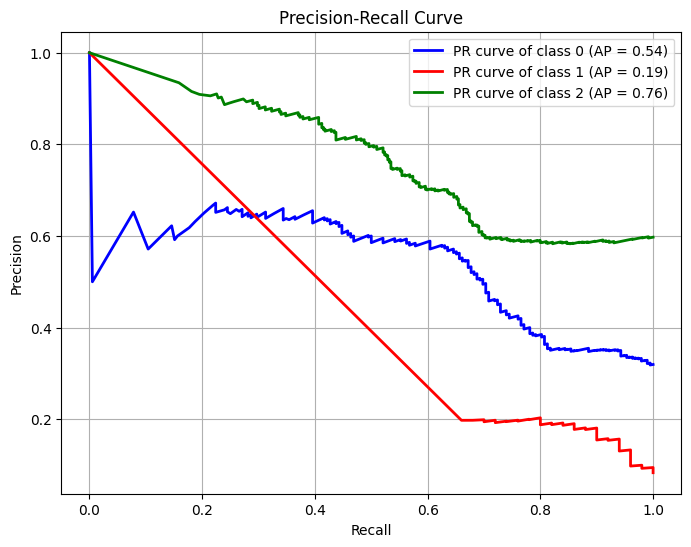

pred_pivots
1.0    240
2.0    181
0.0    180
Name: count, dtype: int64


In [ ]:
from pipeline.visualiser import plot_classification_forecast, plot_roc_auc, plot_pr_auc
from pipeline.predict import predict_dataset_batched

# Предсказания
df_val['pred_pivots'], y_probs = predict_dataset_batched(model, df_val, config, device="cuda")
# print(df_val)
# Выбор валидных индексов, где были предсказания
valid_mask = ~df_val['pred_pivots'].isna()

# Выравнивание по индексу
y_true = df_val.loc[valid_mask, config.forecast].values.astype(int)
y_pred_proba = y_probs[valid_mask.values]  # valid_mask должен быть ndarray такой же длины

# ROC-AUC
plot_roc_auc(y_true, y_pred_proba, n_classes=config.num_classes)

# PR-AUC
plot_pr_auc(y_true, y_pred_proba, n_classes=config.num_classes)

# Диагностика предсказаний
df_val.dropna(inplace=True)
print(df_val['pred_pivots'].value_counts(dropna=False))


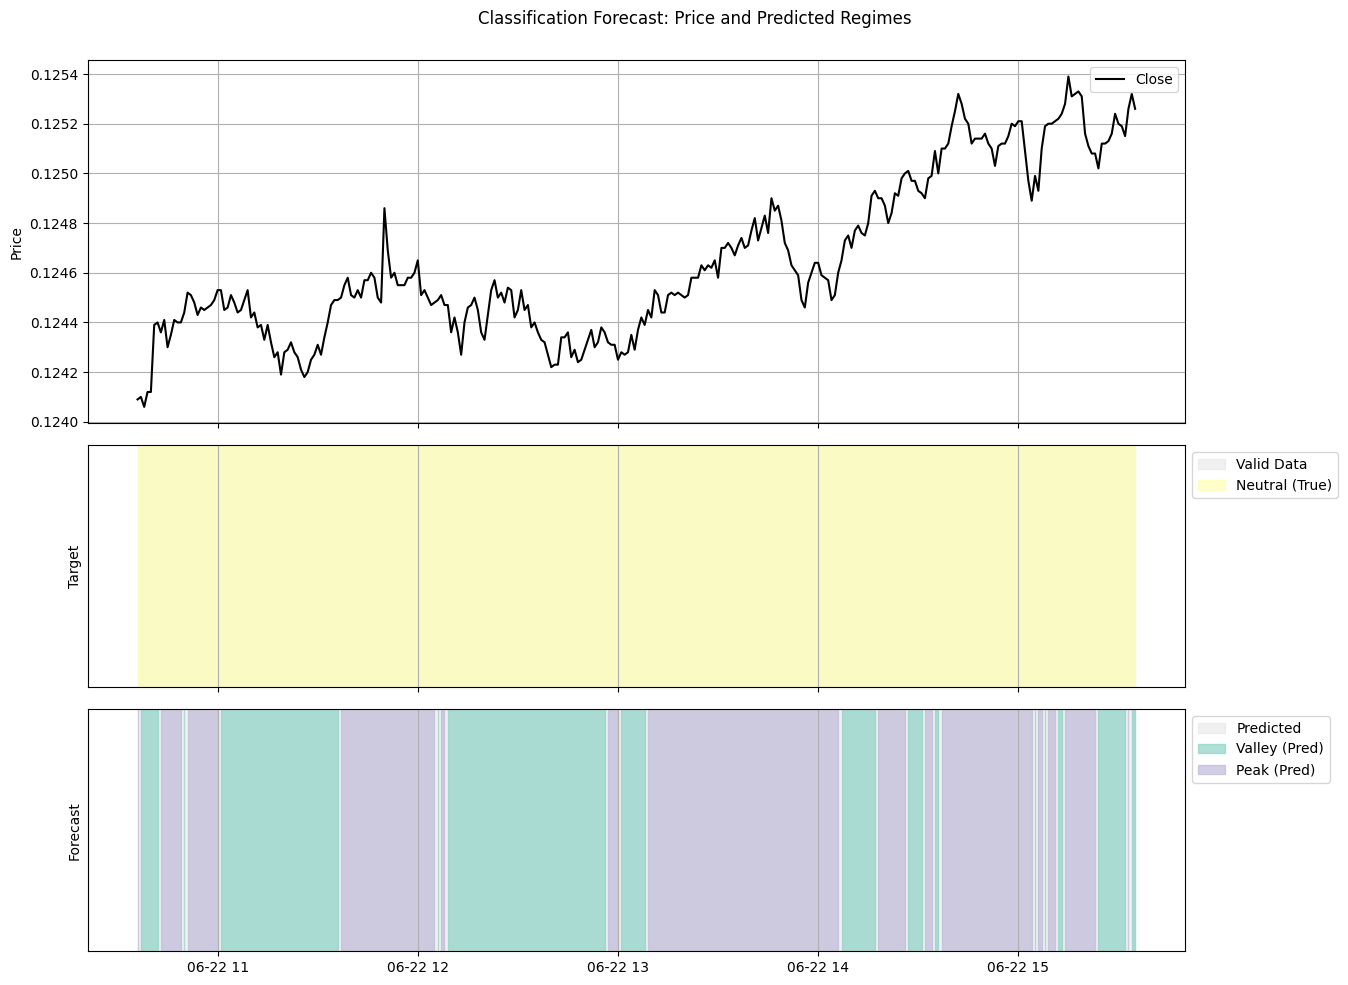

In [ ]:
plot_classification_forecast(
    df_val,
    price_col="Close",
    target_col="pivots",
    forecast_col="pred_pivots",
    class_labels=["Valley", "Neutral", "Peak"],
    start=500,
    length=300,
    title="Classification Forecast: Price and Predicted Regimes"
)